# Mecánica Celeste 
## Cuadraturas 
3 de marzo - Soleil Dayana Niño Murcia

In [4]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

### Aclaración sobre unidades canónicas
Hacia un sistema de unidades más conveniente...
Utilizar factores de conversión \( U_l \), \( U_M \), \( U_T \) se los llama unidades canónicas en mecánica celeste si cumplen que:

\[ G = \frac{U_l^3}{U_M U_T^2} \]

Donde:
- \( U_l \): Factor de conversión para la longitud.
- \( U_M \): Factor de conversión para la masa.
- \( U_T \): Factor de conversión para el tiempo.

Estas unidades permiten simplificar las ecuaciones del movimiento y trabajar en un sistema más natural para problemas gravitacionales.

## Crear un sistema de N cuerpos en Pymcel 
(con unidades canónicas)

In [9]:
sistema = [
    dict(m = 1, r = [0,0,0], v = [0,0,0]),  # si las partículas tienen masa, entonces el sistema no es invariante por traslaciones, y el centro de masas se mueve. Para evitar esto, se puede poner una partícula con masa muy pequeña en el origen, y las otras dos partículas con masa 1 en posiciones opuestas.
    dict(m = 1, r = [1,0,0], v = [0,1,0])
]

In [10]:
ts = np.linspace(0, 10, 100)
rs, vs, rps, vps, ctes = pc.ncuerpos_solucion(sistema, ts)

# Gráficas

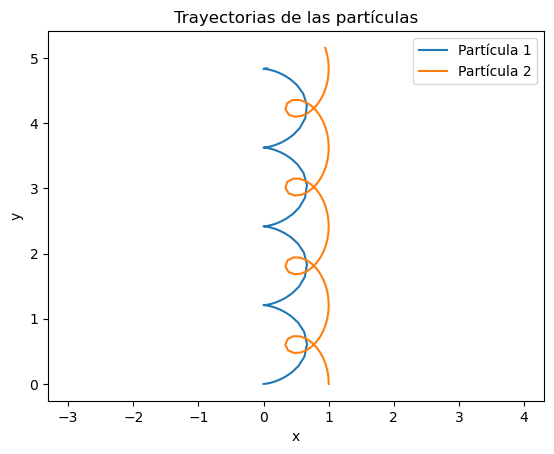

In [13]:
plt.plot(rs[0,:,0], rs[0,:,1], label='Partícula 1')
plt.plot(rs[1,:,0], rs[1,:,1], label='Partícula 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de las partículas')
plt.legend()
plt.axis('equal')
plt.show()

¡OJO! esto es respecto al sistema de coordenadas que definimos en "sistema". 


Ahora, grafiquemos respecto al centro de masa, cambiando rs por rps

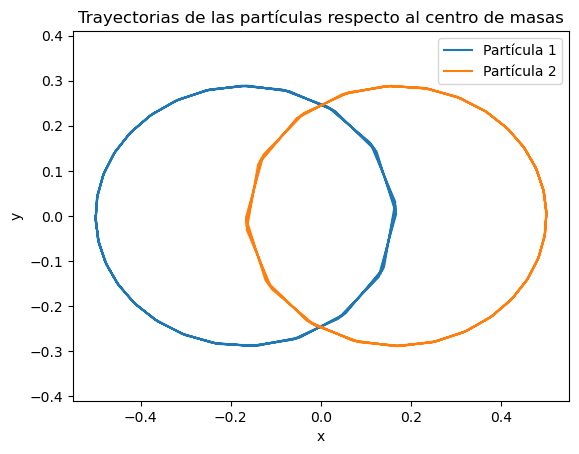

In [14]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Partícula 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Partícula 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de las partículas respecto al centro de masas')
plt.legend()
plt.axis('equal')
plt.show()

## ¿Se mantienen constantes las cuadraturas?

### Momentum lineal total

In [ ]:
sum = 0
for i in range(len(sistema)):
    sum += sistema[i]['m'] * vs[i,0,:] # Esto solo evalúa en t = 0

sum

array([0., 1., 0.])

¿El momentum total es constante en el tiempo? True


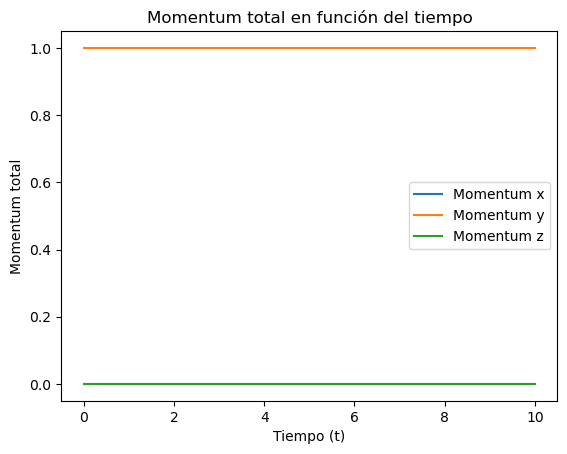

In [17]:
momentum_total = []
for t in range(len(ts)):
    momentum_t = np.sum([sistema[i]['m'] * vs[i, t, :] for i in range(len(sistema))], axis=0)
    momentum_total.append(momentum_t)

# Convertimos a un array para facilitar el análisis
momentum_total = np.array(momentum_total)

# Verificamos si el momentum total es constante
print("¿El momentum total es constante en el tiempo?", np.allclose(momentum_total, momentum_total[0]))

# Graficamos el momentum total en función del tiempo
plt.plot(ts, momentum_total[:, 0], label='Momentum x')
plt.plot(ts, momentum_total[:, 1], label='Momentum y')
plt.plot(ts, momentum_total[:, 2], label='Momentum z')
plt.xlabel('Tiempo (t)')
plt.ylabel('Momentum total')
plt.title('Momentum total en función del tiempo')
plt.legend()
plt.show()

### Momentum angular total

In [21]:
momentum_angular_total = []
for t in range(len(ts)):
    momentum_angular_t = np.sum([sistema[i]['m'] * np.cross(rps[i, t, :], vs[i, t, :]) for i in range(len(sistema))], axis=0)
    momentum_angular_total.append(momentum_angular_t)
# Convertimos a un array para facilitar el análisis
momentum_angular_total = np.array(momentum_angular_total)
# Verificamos si el momentum angular total es constante
print("¿El momentum angular total es constante en el tiempo?", np.allclose(momentum_angular_total, momentum_angular_total[0]))
# Graficamos el momentum angular total en función del tiem



¿El momentum angular total es constante en el tiempo? True


In [25]:
# Con numpy, hacemos la suma en un solo paso, sin necesidad de un loop explícito
# Pero, ojo, esto solo evalúa en t = 0, para evaluar en todos los tiempos, necesitamos un loop o una función vectorizada
np.sum([s['m'] * vs[i, 0, :] for i, s in enumerate(sistema)], axis=0)

# Calcular en todos los momentos variando el segundo índice
momentum_total = np.sum([s['m'] * vs[i, :, :] for i, s in enumerate(sistema)], axis=0)
momentum_total.shape # Esto nos da (100, 3), es decir, el momentum total en cada uno de los 100 tiempos, con sus componentes x, y, z
# Verificamos si el momentum total es constante en el tiempo
print("¿El momentum total es constante en el tiempo?", np.allclose(momentum_total, momentum_total[0]))  
momentum_total

¿El momentum total es constante en el tiempo? True


array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1